## 1. IMPORT

In [1]:
# --- Setup Colab: clone repo dari GitHub HANYA kalau dijalankan di Colab ---
# Kalau dijalankan lokal (sudah berada di dalam clone repo ini), cell ini
# tidak melakukan apa-apa -- path relatif (../src, ../data, ../models) tetap
# mengacu ke file lokal Anda yang sudah ada, bukan clone baru.
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_URL = 'https://github.com/mdn1021/lstm-yang-dioptimasi-HHO.git'
    BRANCH = 'claude/optimized-model-performance-ipdvtz'
    REPO_DIR = 'lstm-yang-dioptimasi-HHO'

    if not os.path.exists(REPO_DIR):
        !git clone -b {BRANCH} {REPO_URL}

    %cd {REPO_DIR}/notebooks
else:
    print("Dijalankan lokal -- pakai file yang sudah ada, tidak clone ulang.")


Dijalankan lokal -- pakai file yang sudah ada, tidak clone ulang.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import random
import sys
import logging

sys.path.append('../src')

from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

from data_utils_return import prepare_source_return, inverse_return_to_price, TARGET_COLS, N_FEATURES, CLOSE_IDX
from model_utils import build_lstm_mimo, DEFAULT_EPOCHS, DEFAULT_PATIENCE
from evaluation import print_evaluation_report, summary_table

logging.getLogger('tensorflow').setLevel(logging.ERROR)
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# Global style - konsisten dengan notebook LSTM+HHO
_C = dict(
    train   = '#A0AEC0',
    val_act = '#63B3ED',
    act     = '#378ADD',
    val_p   = '#EF9F27',
    test_p  = '#E24B4A',
    split   = '#1D9E75',
    loss_tr = '#378ADD',
    loss_va = '#EF9F27',
)
HORIZON_COLORS = ['#1D9E75', '#63B3ED', '#EF9F27', '#E24B4A', '#7F77DD']

plt.rcParams.update({
    'figure.facecolor' : '#FFFFFF',
    'axes.facecolor'   : '#FFFFFF',
    'axes.edgecolor'   : '#E2E8F0',
    'axes.linewidth'   : 0.8,
    'axes.grid'        : True,
    'grid.color'       : '#E2E8F0',
    'grid.linewidth'   : 0.6,
    'grid.alpha'       : 1.0,
    'xtick.color'      : '#888888',
    'ytick.color'      : '#888888',
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'font.family'      : 'sans-serif',
    'font.size'        : 10,
    'text.color'       : '#1A202C',
})

def _spine(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def _fmt_usd(ax):
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

def _fmt_date(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.get_xticklabels(), rotation=0, ha='center')

def _subtitle(ax, txt):
    ax.annotate(txt, xy=(0, 1.04), xycoords='axes fraction',
                fontsize=8.5, color='#718096')


I0000 00:00:1785003142.911346    3772 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785003142.976723    3772 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785003145.936534    3772 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. LOAD DATA

In [3]:
ds = prepare_source_return('nasdaq', n_input=60, n_forecast=5, data_dir='../data')
data = ds['data']

print(f"Data shape : {data.shape}")
print(f"Periode    : {data.index[0].date()} -> {data.index[-1].date()}")


Data shape : (1336, 5)
Periode    : 2021-01-04 -> 2026-04-29


## 3. TRANSFORMASI KE RETURN (Percentage Change)

> **PENTING - konsisten dengan notebook LSTM MIMO + HHO.**
> Baseline versi ini TIDAK LAGI menormalisasi harga absolut langsung dengan
> Min-Max, melainkan mentransformasi OHLC menjadi *percentage change* harian
> (dan Volume menjadi log-return), baru kemudian di-scale. Alasannya:
> Min-Max pada harga absolut membuat model gagal ekstrapolasi ketika harga
> NVDA bergerak ke rentang yang belum pernah terlihat saat training (price
> jump), sehingga prediksi "menempel" ke level harga lama. Return-based
> normalization tidak punya masalah ini, karena skala return harian relatif
> stabil meski harga absolut terus naik.
>
> Perubahan ini diterapkan **sama persis** ke baseline maupun HHO, supaya
> perbandingan performa antar keduanya adil (BAB 3.6.2) — perbedaan hasil
> semata-mata berasal dari ada/tidaknya optimasi hyperparameter, bukan dari
> preprocessing yang berbeda.

In [4]:
data_ret = ds['data_ret']
close_abs = ds['close_abs']

print(f"data_ret shape : {data_ret.shape}")
print(data_ret.describe().round(3))


data_ret shape : (1335, 5)
           Open      High       Low     Close    Volume
count  1335.000  1335.000  1335.000  1335.000  1335.000
mean      0.264     0.246     0.252     0.259     4.614
std       3.330     2.851     2.989     3.235     0.278
min     -15.886   -13.808   -17.747   -16.968     3.518
25%      -1.494    -1.362    -1.402    -1.577     4.442
50%       0.241     0.131     0.300     0.284     4.594
75%       2.156     1.701     1.864     2.047     4.778
max      27.517    28.990    22.911    24.370     6.178


## 4. WALK-FORWARD SPLIT (70 / 15 / 15)

> Split dilakukan pada `data_ret` (setelah transformasi return), time-ordered, identik dengan notebook LSTM MIMO + HHO.

In [5]:
train_ret, val_ret, test_ret = ds['train_ret'], ds['val_ret'], ds['test_ret']
train_close_abs = close_abs.loc[train_ret.index]
val_close_abs   = close_abs.loc[val_ret.index]
test_close_abs  = close_abs.loc[test_ret.index]

print("=" * 65)
print("  WALK-FORWARD SPLIT (70/15/15) - LSTM MIMO Standar (Baseline, Return)")
print("=" * 65)
for label, d in [("Train", train_ret), ("Val", val_ret), ("Test", test_ret)]:
    print(f"  {label:<6} | {d.index[0].date()} -> {d.index[-1].date()} "
          f"| {len(d):>4} baris")


  WALK-FORWARD SPLIT (70/15/15) - LSTM MIMO Standar (Baseline, Return)
  Train  | 2021-01-05 -> 2024-09-23 |  935 baris
  Val    | 2024-09-24 -> 2025-07-14 |  200 baris
  Test   | 2025-07-15 -> 2026-04-29 |  200 baris


## 5. NORMALISASI (Min-Max pada Return, fit hanya pada Train)

In [6]:
scaler = ds['scaler']
train_scaled, val_scaled, test_scaled = ds['train_scaled'], ds['val_scaled'], ds['test_scaled']

print("Close return - scaler range (fit pada train):")
print(f"  min : {scaler.data_min_[CLOSE_IDX]:.4f}")
print(f"  max : {scaler.data_max_[CLOSE_IDX]:.4f}")


Close return - scaler range (fit pada train):
  min : -10.0046
  max : 24.3696


## 6. PEMBUATAN DATASET MIMO

In [7]:
n_input, n_forecast = ds['n_input'], ds['n_forecast']
X_train, y_train = ds['X_train'], ds['y_train']
X_val,   y_val   = ds['X_val'],   ds['y_val']
X_test,  y_test  = ds['X_test'],  ds['y_test']

print(f"X_train : {X_train.shape}  -> (samples, n_input={n_input}, N_FEATURES={N_FEATURES})")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}  -> (samples, n_forecast={n_forecast}) [skala return, 0-1]")


X_train : (870, 60, 5)  -> (samples, n_input=60, N_FEATURES=5)
X_val   : (135, 60, 5)
X_test  : (135, 60, 5)
y_train : (870, 5)  -> (samples, n_forecast=5) [skala return, 0-1]


## 7. ANCHOR HARGA & GROUND TRUTH ABSOLUT

Karena target model sekarang berupa **return** (bukan harga absolut), setiap
sampel butuh **anchor**: harga Close absolut pada hari terakhir window input.
Prediksi return kemudian direkonstruksi kembali ke USD lewat
`base_price * exp(cumulative_log_return)` — bukan `inverse_transform` biasa.

In [8]:
base_train, base_val, base_test = ds['base_train'], ds['base_val'], ds['base_test']
y_train_abs = ds['y_train_abs']
y_val_abs   = ds['y_val_abs']
y_test_abs  = ds['y_test_abs']

print(f"y_train_abs : {y_train_abs.shape}  -> harga aktual dalam USD")
print(f"y_val_abs   : {y_val_abs.shape}")
print(f"y_test_abs  : {y_test_abs.shape}")
print(f"\nSample y_test_abs terakhir : {y_test_abs[-1].round(2)}")


y_train_abs : (870, 5)  -> harga aktual dalam USD
y_val_abs   : (135, 5)
y_test_abs  : (135, 5)

Sample y_test_abs terakhir : [202.5  199.64 208.27 216.61 213.17]


## 8. ARSITEKTUR MODEL LSTM MIMO STANDAR (Baseline)

Hyperparameter default sesuai BAB 3.5.1 (Tabel Arsitektur Model LSTM) — **tidak**
dioptimasi (ini adalah model baseline, dibandingkan dengan LSTM+HHO pada notebook lain).

| Hyperparameter        | Nilai Default |
|---|---|
| LSTM Layer 1 units    | 128 |
| LSTM Layer 2 units    | 64  |
| Dropout Rate          | 0.2 |
| Optimizer             | Adam |
| Learning rate         | 0.001 |
| Batch Size            | 32 |

In [9]:
UNITS_1        = 128
UNITS_2        = 64
DROPOUT_RATE   = 0.2
LEARNING_RATE  = 0.001
BATCH_SIZE     = 32
EPOCHS         = DEFAULT_EPOCHS
PATIENCE       = DEFAULT_PATIENCE

model = build_lstm_mimo(n_input, N_FEATURES, n_forecast,
                         UNITS_1, UNITS_2, DROPOUT_RATE, DROPOUT_RATE, LEARNING_RATE)
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,341 (462.27 KB)

 Trainable params: 118,341 (462.27 KB)

 Non-trainable params: 0 (0.00 B)

## 9. TRAINING MODEL

In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE,
                           restore_best_weights=True, verbose=0)

print("\nTraining LSTM MIMO Standar (baseline, hyperparameter default, return-based)...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    shuffle=False, callbacks=[early_stop], verbose=1
)
print(f"\nTraining selesai pada epoch ke-{len(history.history['loss'])}")



Training LSTM MIMO Standar (baseline, hyperparameter default, return-based)...
Epoch 1/100


 1/28 ━━━━━━━━━━━━━━━━━━━━ 2:08 5s/step - loss: 0.1065

 2/28 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.1013

 3/28 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 0.0939

 4/28 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0870

...

25/28 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0092

26/28 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0092

27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0093

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.0104 - val_loss: 0.0124



Training selesai pada epoch ke-38


## 10. PREDIKSI & REKONSTRUKSI HARGA (Anchor-based)

In [11]:
train_pred_scaled = model.predict(X_train)
val_pred_scaled   = model.predict(X_val)
test_pred_scaled  = model.predict(X_test)

train_predict = inverse_return_to_price(scaler, train_pred_scaled, base_train, n_forecast)
val_predict   = inverse_return_to_price(scaler, val_pred_scaled,   base_val,   n_forecast)
test_predict  = inverse_return_to_price(scaler, test_pred_scaled,  base_test,  n_forecast)

print(f"train_predict : {train_predict.shape}  (dalam USD)")
print(f"val_predict   : {val_predict.shape}")
print(f"test_predict  : {test_predict.shape}")
print(f"\nSample test_predict terakhir : {test_predict[-1].round(2)}")
print(f"Ground truth terakhir        : {y_test_abs[-1].round(2)}")


 1/28 ━━━━━━━━━━━━━━━━━━━━ 7s 275ms/step

 4/28 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step 

 7/28 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

10/28 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

13/28 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


train_predict : (870, 5)  (dalam USD)
val_predict   : (135, 5)
test_predict  : (135, 5)

Sample test_predict terakhir : [200.57 200.96 201.87 202.35 202.58]
Ground truth terakhir        : [202.5  199.64 208.27 216.61 213.17]


## 11. EVALUASI (RMSE, MAE, MAPE, DA per Horizon)


In [12]:
splits = {
    'TRAIN': (y_train_abs, train_predict, base_train),
    'VAL':   (y_val_abs,   val_predict,   base_val),
    'TEST':  (y_test_abs,  test_predict,  base_test),
}

print_evaluation_report("LSTM MIMO Standar (Baseline, Return-Based) - Nasdaq", n_forecast, splits)

val_dates  = ds['val_dates']
test_dates = ds['test_dates']



  EVALUASI TRAIN SET - LSTM MIMO Standar (Baseline, Return-Based) - Nasdaq
  Horizon t+1 (Hari ke-1) | RMSE=  1.8196  MAE=  1.0316  MAPE=2.53%  DA=53.79%
  Horizon t+2 (Hari ke-2) | RMSE=  2.4424  MAE=  1.4605  MAPE=3.66%  DA=54.94%
  Horizon t+3 (Hari ke-3) | RMSE=  3.0374  MAE=  1.7886  MAPE=4.42%  DA=57.47%
  Horizon t+4 (Hari ke-4) | RMSE=  3.4894  MAE=  2.0695  MAPE=5.08%  DA=57.13%
  Horizon t+5 (Hari ke-5) | RMSE=  3.9391  MAE=  2.3417  MAPE=5.68%  DA=58.51%

  Average (all horizons)   | RMSE=  3.0396  MAE=  1.7384  MAPE=4.28%  DA=56.37%

  EVALUASI VAL SET - LSTM MIMO Standar (Baseline, Return-Based) - Nasdaq
  Horizon t+1 (Hari ke-1) | RMSE=  4.6642  MAE=  3.2879  MAPE=2.67%  DA=55.56%
  Horizon t+2 (Hari ke-2) | RMSE=  6.2079  MAE=  4.6553  MAPE=3.78%  DA=57.78%
  Horizon t+3 (Hari ke-3) | RMSE=  7.9022  MAE=  5.9257  MAPE=4.84%  DA=60.00%
  Horizon t+4 (Hari ke-4) | RMSE=  8.8955  MAE=  6.9960  MAPE=5.71%  DA=60.74%
  Horizon t+5 (Hari ke-5) | RMSE=  9.6916  MAE=  7.7981  M

## 12. TABEL RINGKASAN EVALUASI (RMSE, MAE, MAPE, DA)


In [13]:
summary_table("LSTM MIMO Standar (Baseline, Return-Based) - Nasdaq", n_forecast, splits)



  RINGKASAN EVALUASI - LSTM MIMO Standar (Baseline, Return-Based) - Nasdaq
  Set      Horizon              RMSE        MAE       MAPE       DA
  ----------------------------------------------------------------
  TRAIN    t+1 (Hari ke-1)     1.8196     1.0316      2.53%   53.79%
  TRAIN    t+2 (Hari ke-2)     2.4424     1.4605      3.66%   54.94%
  TRAIN    t+3 (Hari ke-3)     3.0374     1.7886      4.42%   57.47%
  TRAIN    t+4 (Hari ke-4)     3.4894     2.0695      5.08%   57.13%
  TRAIN    t+5 (Hari ke-5)     3.9391     2.3417      5.68%   58.51%
  TRAIN    Average            3.0396     1.7384      4.28%   56.37%
  ----------------------------------------------------------------
  VAL      t+1 (Hari ke-1)     4.6642     3.2879      2.67%   55.56%
  VAL      t+2 (Hari ke-2)     6.2079     4.6553      3.78%   57.78%
  VAL      t+3 (Hari ke-3)     7.9022     5.9257      4.84%   60.00%
  VAL      t+4 (Hari ke-4)     8.8955     6.9960      5.71%   60.74%
  VAL      t+5 (Hari ke-5)     9.

  VAL      Average            7.6915     5.7326      4.67%   59.56%
  ----------------------------------------------------------------
  TEST     t+1 (Hari ke-1)     4.2342     3.3068      1.79%   53.33%
  TEST     t+2 (Hari ke-2)     5.9186     4.5077      2.44%   52.59%
  TEST     t+3 (Hari ke-3)     7.2975     5.6163      3.04%   53.33%
  TEST     t+4 (Hari ke-4)     8.4777     6.6379      3.58%   49.63%
  TEST     t+5 (Hari ke-5)     9.0873     7.2959      3.92%   51.11%
  TEST     Average            7.2203     5.4729      2.95%   52.00%
  ----------------------------------------------------------------


## 13. PLOT - Training & Validation Loss

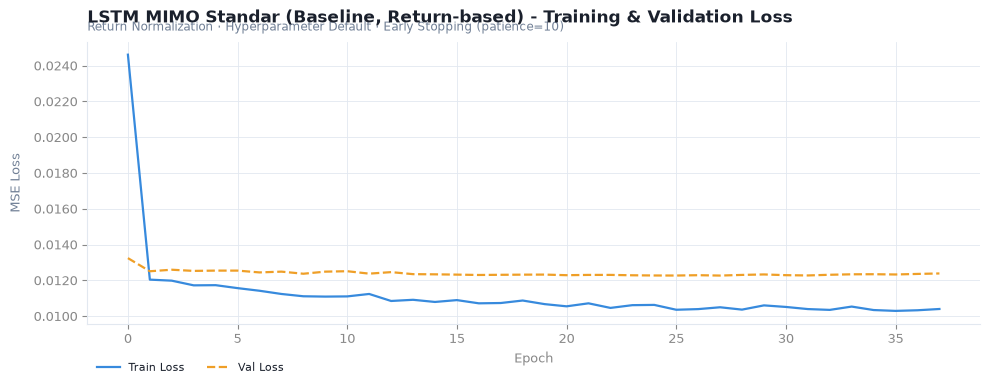

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.subplots_adjust(top=0.86, bottom=0.12, left=0.09, right=0.97)

ax.plot(history.history['loss'],     color=_C['loss_tr'], lw=1.6, label='Train Loss')
ax.plot(history.history['val_loss'], color=_C['loss_va'], lw=1.6, label='Val Loss', ls='--')

_spine(ax)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.4f}'))
ax.set_ylabel('MSE Loss', fontsize=9, color='#718096', labelpad=8)
ax.set_xlabel('Epoch', fontsize=9, color='#888888')
ax.set_title('LSTM MIMO Standar (Baseline, Return-based) - Training & Validation Loss',
             fontsize=12, fontweight='bold', color='#1A202C', loc='left', pad=14)
_subtitle(ax, f'Return Normalization · Hyperparameter Default · Early Stopping (patience={PATIENCE})')

handles = [
    mlines.Line2D([], [], color=_C['loss_tr'], lw=1.6,          label='Train Loss'),
    mlines.Line2D([], [], color=_C['loss_va'], lw=1.6, ls='--', label='Val Loss'),
]
ax.legend(handles=handles, fontsize=8, frameon=False, ncol=2,
          loc='upper left', bbox_to_anchor=(0, -0.10))
plt.tight_layout(); plt.show()


## 14. PLOT - Aktual vs Prediksi (t+1)

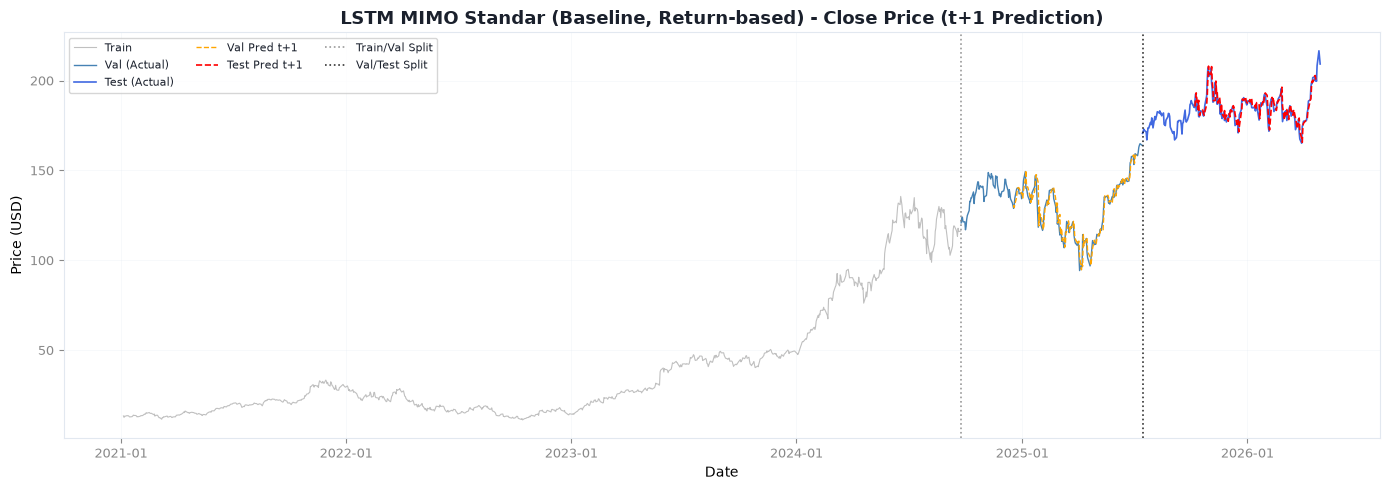

In [15]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_close_abs.index, train_close_abs,
        label='Train', color='silver', lw=0.8)
ax.plot(val_close_abs.index, val_close_abs,
        label='Val (Actual)', color='steelblue', lw=1.0)
ax.plot(test_close_abs.index, test_close_abs,
        label='Test (Actual)', color='royalblue', lw=1.2)
ax.plot(val_dates,  val_predict[:, 0],
        label='Val Pred t+1',  ls='--', color='orange', lw=1.0)
ax.plot(test_dates, test_predict[:, 0],
        label='Test Pred t+1', ls='--', color='red',    lw=1.2)
ax.axvline(val_ret.index[0],  color='gray',  lw=1.2, ls=':', alpha=0.8, label='Train/Val Split')
ax.axvline(test_ret.index[0], color='black', lw=1.2, ls=':', alpha=0.8, label='Val/Test Split')
ax.set_title('LSTM MIMO Standar (Baseline, Return-based) - Close Price (t+1 Prediction)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD)'); ax.legend(fontsize=8, ncol=3)
ax.grid(alpha=0.3); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlabel('Date'); plt.tight_layout(); plt.show()


## 15. PLOT - MIMO Forecast (Semua Horizon)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


findfont: Failed to find font weight 500, now using 400.


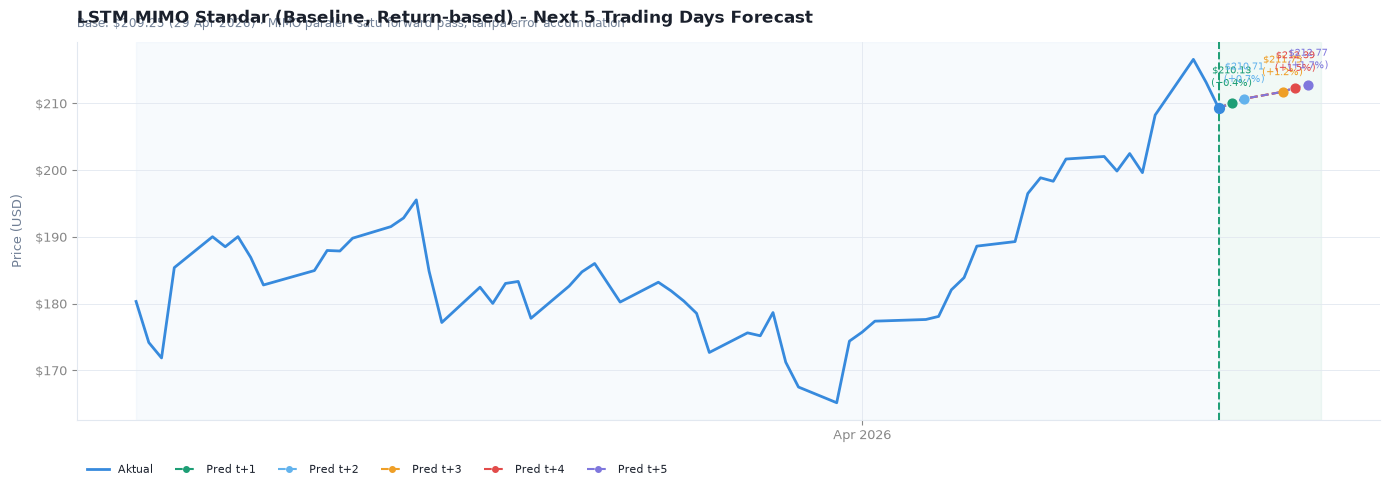

In [16]:
last_seq      = test_scaled[-n_input:].reshape(1, n_input, N_FEATURES)
last_pred_raw = model.predict(last_seq)
last_price    = float(close_abs.iloc[-1])
last_pred_inv = inverse_return_to_price(scaler, last_pred_raw, np.array([last_price]), n_forecast)[0]

last_date    = data.index[-1]
future_dates = pd.bdate_range(start=last_date, periods=n_forecast + 1)[1:]

lookback   = 60
hist_dates = test_close_abs.index[-lookback:]
hist_close = test_close_abs.iloc[-lookback:].values

fig2, ax2 = plt.subplots(figsize=(14, 5))
fig2.subplots_adjust(top=0.88, bottom=0.13, left=0.07, right=0.98)

ax2.axvspan(hist_dates[0], last_date, color=_C['act'],   alpha=0.04, zorder=0)
ax2.axvspan(last_date, future_dates[-1] + pd.tseries.offsets.BDay(1),
            color=_C['split'], alpha=0.06, zorder=0)
ax2.axvline(x=last_date, color=_C['split'], lw=1.4, ls='--', zorder=3)

ax2.plot(hist_dates, hist_close, color=_C['act'], lw=2.0,
         label='Aktual (60h terakhir)', zorder=5)
ax2.scatter([last_date], [last_price], color=_C['act'], s=50, zorder=6)

for i in range(n_forecast):
    x_line = [last_date] + list(future_dates[:i + 1])
    y_line = [last_price] + list(last_pred_inv[:i + 1])
    ax2.plot(x_line, y_line, ls='--', lw=1.5, color=HORIZON_COLORS[i],
             label=f'Pred t+{i+1}', zorder=4)
    ax2.scatter([future_dates[i]], [last_pred_inv[i]], color=HORIZON_COLORS[i], s=40, zorder=5)
    diff = last_pred_inv[i] - last_price
    sign = '+' if diff >= 0 else ''
    pct  = diff / last_price * 100
    ax2.annotate(f'${last_pred_inv[i]:.2f}\n({sign}{pct:.1f}%)',
                 xy=(future_dates[i], last_pred_inv[i]),
                 xytext=(0, 12), textcoords='offset points',
                 ha='center', fontsize=7.5, color=HORIZON_COLORS[i], fontweight='500')

_spine(ax2); _fmt_usd(ax2); _fmt_date(ax2)
ax2.set_ylabel('Price (USD)', fontsize=9, color='#718096', labelpad=8)
ax2.set_title(f'LSTM MIMO Standar (Baseline, Return-based) - Next {n_forecast} Trading Days Forecast',
              fontsize=12, fontweight='bold', color='#1A202C', loc='left', pad=14)
_subtitle(ax2, f'Base: ${last_price:.2f} ({last_date.strftime("%d %b %Y")}) '
    '· MIMO paralel - satu forward pass, tanpa error accumulation')

handles2 = [mlines.Line2D([], [], color=_C['act'], lw=2.0, label='Aktual')]
for i in range(n_forecast):
    handles2.append(mlines.Line2D([], [], color=HORIZON_COLORS[i],
                                  lw=1.5, ls='--', marker='o',
                                  markersize=4, label=f'Pred t+{i+1}'))
ax2.legend(handles=handles2, fontsize=8, ncol=6, frameon=False,
           loc='upper left', bbox_to_anchor=(0, -0.09))
plt.tight_layout(); plt.show()


## 16. SIMPAN MODEL & METADATA

In [17]:
import json, os

os.makedirs('../models', exist_ok=True)
model.save('../models/lstm_mimo_baseline_nasdaq.h5')

metadata = {
    "model_name": "LSTM MIMO Standar (Baseline)",
    "source": "nasdaq",
    "n_input": n_input,
    "n_forecast": n_forecast,
    "features": TARGET_COLS,
    "hyperparameters": {
        "units_1": UNITS_1, "units_2": UNITS_2,
        "dropout_rate": DROPOUT_RATE, "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE
    },
    "normalization": "Return (percentage change) + MinMaxScaler, fit pada train only; rekonstruksi harga via anchor + cumulative log-return",
    "split": "70/15/15 (walk-forward, time-ordered)"
}
with open('../models/lstm_mimo_baseline_nasdaq_meta.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Model dan metadata baseline (return-based) tersimpan di folder 'models/'.")


Model dan metadata baseline (return-based) tersimpan di folder 'models/'.
